In [93]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

In [94]:
import sys
sys.path.insert(0, '..')

In [95]:
import cv2
from court_line_detector import CourtLineDetector

cap = cv2.VideoCapture('../input-videos/input_video.mp4')
ret, frame = cap.read()
cap.release()

court_line_detector = CourtLineDetector('../models/keypoints_model.pt')
court_keypoints = court_line_detector.predict(frame)

# flat array of 28 values: [x0, y0, x1, y1, ..., x13, y13]
print(court_keypoints)

[ 605.2514   304.889   1321.6658   305.0881   331.26578  860.07446
 1586.1431   860.54694  694.68036  305.04117  489.03726  859.9911
 1232.4359   304.541   1427.6436   860.442    664.4397   385.9719
 1261.1036   385.7247   559.8361   668.2661  1359.2736   668.1745
  961.92065  386.20718  959.4185   668.1293 ]


In [96]:
# Read the pickle file
with open('../tracker_stubs/ball_detections.pkl', 'rb') as f:
    ball_positions = pickle.load(f)

with open('../tracker_stubs/player_detections.pkl', 'rb') as f2:
    player_positions = pickle.load(f2)

In [97]:
def get_center_bbox(bbox):
    x1, y1, x2, y2 = bbox
    return (int((x1 + x2) / 2), int((y1 + y2) / 2))

def measure_distance(p1, p2):
    return ((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2) ** 0.5

def choose_players(court_keypoints, player_dict):
    distances = []
    for track_id, bbox in player_dict.items():
        player_center = get_center_bbox(bbox)
        dists = sorted(
            measure_distance(player_center, (court_keypoints[i], court_keypoints[i+1]))
            for i in range(0, len(court_keypoints), 2)
        )
        distances.append((track_id, sum(dists[:3]) / 3))
    distances.sort(key = lambda x: x[1])
    return [distances[0][0], distances[1][0]]

chosen_players = choose_players(court_keypoints, player_positions[0])
print("Chosen player IDs:", chosen_players)

player_positions = [
    {tid: bbox for tid, bbox in frame.items() if tid in chosen_players}
    for frame in player_positions
]

Chosen player IDs: [1, 2]


In [98]:
rows = []
for frame in player_positions:
    row = {}
    for player_id, bbox in frame.items():
        row[f'player_{player_id}_x1'] = bbox[0]
        row[f'player_{player_id}_y1'] = bbox[1]
        row[f'player_{player_id}_x2'] = bbox[2]
        row[f'player_{player_id}_y2'] = bbox[3]
    rows.append(row)

df_player_positions = pd.DataFrame(rows)
df_player_positions = df_player_positions.interpolate().bfill()
df_player_positions.head()

,player_1_x1,player_1_y1,player_1_x2,player_1_y2,player_2_x1,player_2_y1,player_2_x2,player_2_y2
0,480.310669,751.776001,624.798950,930.447571,1031.101562,201.722900,1095.798218,308.670502
1,481.510071,750.114685,632.787720,931.160339,1032.334351,202.984222,1101.834351,309.105652
2,484.013733,749.155457,646.879578,931.103516,1032.163330,205.510956,1098.139282,308.838379
3,491.473206,746.029053,662.228271,930.881775,1033.442261,208.101700,1096.458740,308.499481
4,498.740631,744.690247,673.259521,930.604553,1036.024780,207.986435,1096.077637,307.620300


In [99]:
df_player_positions['p1_mid_y'] = (df_player_positions['player_1_y1'] + df_player_positions['player_1_y2']) // 2
df_player_positions['p2_mid_y'] = (df_player_positions['player_2_y1'] + df_player_positions['player_2_y2']) // 2

In [100]:
ball_positions = [x.get(1, []) for x in ball_positions]
df_ball_positions = pd.DataFrame(ball_positions, columns = ['x1', 'y1', 'x2', 'y2'])

# Interpolate the missing values
df_ball_positions = df_ball_positions.interpolate()
df_ball_positions = df_ball_positions.bfill()

In [101]:
df_ball_positions.head(5)

,x1,y1,x2,y2
0,895.415771,618.071777,912.313477,635.559631
1,895.415771,618.071777,912.313477,635.559631
2,873.901245,638.229492,895.586975,658.988586
3,859.940918,645.812683,881.553406,670.207275
4,847.489807,659.532389,867.009216,681.258647


In [102]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2']) / 2
df_ball_positions['mid_x'] = (df_ball_positions['x1'] + df_ball_positions['x2']) / 2

In [103]:
df_ball_positions.head(5)

,x1,y1,x2,y2,mid_y,mid_x
0,895.415771,618.071777,912.313477,635.559631,626.815704,903.864624
1,895.415771,618.071777,912.313477,635.559631,626.815704,903.864624
2,873.901245,638.229492,895.586975,658.988586,648.609039,884.744110
3,859.940918,645.812683,881.553406,670.207275,658.009979,870.747162
4,847.489807,659.532389,867.009216,681.258647,670.395518,857.249512


Candidate hit frames: [10, 56, 94, 133, 176]


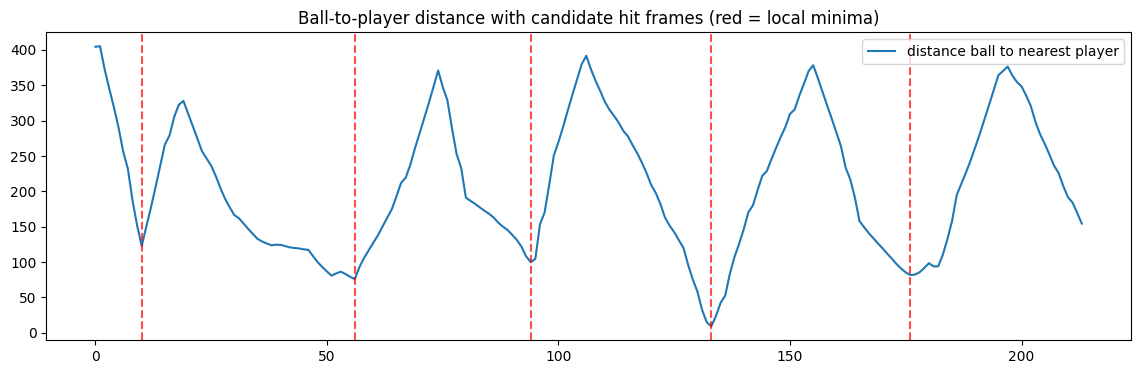

In [105]:
p1_id, p2_id = chosen_players

# Player 1 bbox center x and y per frame
p1_cx = (df_player_positions[f'player_{p1_id}_x1'] + df_player_positions[f'player_{p1_id}_x2']) / 2
p1_cy = (df_player_positions[f'player_{p1_id}_y1'] + df_player_positions[f'player_{p1_id}_y2']) / 2

# Player 2 bbox center x and y per frame
p2_cx = (df_player_positions[f'player_{p2_id}_x1'] + df_player_positions[f'player_{p2_id}_x2']) / 2
p2_cy = (df_player_positions[f'player_{p2_id}_y1'] + df_player_positions[f'player_{p2_id}_y2']) / 2

# Ball center x and y per frame as arrays
bx = df_ball_positions['mid_x'].values
by = df_ball_positions['mid_y'].values

# Distance from ball to each player per frame
dist_p1 = ((bx - p1_cx.values) ** 2 + (by - p1_cy.values) ** 2) ** 0.5
dist_p2 = ((bx - p2_cx.values) ** 2 + (by - p2_cy.values) ** 2) ** 0.5

# Per frame: how close is the ball to the nearest player
min_dist = pd.Series(np.minimum(dist_p1, dist_p2))

# Local minima in distance = ball at its closest point to a player = hit moment
peaks, _ = find_peaks(-min_dist, prominence = 50, distance = 15)
candidate_frames_2d = min_dist.index[peaks].tolist()
print("Candidate hit frames:", candidate_frames_2d)

fig, ax = plt.subplots(figsize = (14, 4))
ax.plot(min_dist, label = 'distance ball to nearest player')
for f in candidate_frames_2d:
    ax.axvline(f, color = 'red', alpha = 0.7, linestyle = '--')
ax.set_title('Ball-to-player distance with candidate hit frames (red = local minima)')
ax.legend()
plt.show()